#### Read one table from tableau (.hyper) as dataframe

In [1]:
import pantab

# Return one table as dataframe
df = pantab.frame_from_hyper("ecommerce_cleaned.hyper", table="AmazonSales") 
df.head(3)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,__index_level_0__
0,72445,407-9563819-7262769,2022-05-13 00:00:00,Shipped,Amazon,Amazon.in,Expedited,J0010,J0010-LCD-XXXL,Set,...,1,INR,999.0,VILLUPURAM,TAMIL NADU,605602.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,72445
1,72443,407-9563819-7262769,2022-05-13 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET295,SET295-KR-NP-XXXL,Set,...,1,INR,799.0,VILLUPURAM,TAMIL NADU,605602.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,72443
2,72444,407-9563819-7262769,2022-05-13 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET415,SET415-KR-NP-XXXL,Set,...,1,INR,999.0,VILLUPURAM,TAMIL NADU,605602.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,72444


#### Read multiple tables from tableau (.hyper) as dictionary

In [3]:
import pantab 

# The keys are (schema, table) tuples, the values are DataFrames
tables_dict = pantab.frames_from_hyper("ecommerce_cleaned.hyper")

# List all tables found in the file
tables = {key[1] for key in tables_dict.keys()}
schemas = {key[0] for key in tables_dict.keys()}
print("Tables found:", tables)
print("Unique schemas in this file:", schemas)

Tables found: {'AmazonSales'}
Unique schemas in this file: {'public'}


In [4]:
# Access a specific table using its schema and name
df = tables_dict[("public", "AmazonSales")]
print(df.head())

    index             Order ID                 Date   Status Fulfilment  \
0   72960  406-7332045-4531529  2022-05-12 00:00:00  Shipped     Amazon   
1   60343  171-8539794-9233923  2022-05-23 00:00:00  Shipped     Amazon   
2   57601  407-0556079-9216341  2022-05-25 00:00:00  Shipped     Amazon   
3  119114  407-3376280-9983545  2022-06-07 00:00:00  Shipped     Amazon   
4  117992  403-2491930-8439525  2022-06-08 00:00:00  Shipped     Amazon   

  Sales Channel  ship-service-level   Style             SKU Category  ... Qty  \
0      Amazon.in          Expedited   J0349     J0349-SET-L      Set  ...   1   
1      Amazon.in          Expedited  SET087  SET087-KR-PP-L      Set  ...   1   
2      Amazon.in          Expedited   J0285     J0285-SKD-L      Set  ...   1   
3      Amazon.in          Expedited   J0349     J0349-SET-L      Set  ...   1   
4      Amazon.in          Expedited   J0244     J0244-SKD-L      Set  ...   1   

  currency  Amount      ship-city ship-state  ship-postal-code

### Opens a Tableau-like drag-and-drop interface using pygwalker

In [5]:
import pygwalker as pyg

pyg.walk(df)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064f17d91a5df38hS2tFTqUkeQLfZu" style="height: auto">\n    <hea…

### Visualizing SQL Results

        Category        total
0  Western Dress  11216072.69
1   Ethnic Dress    791217.66
2         Bottom    150667.98
3            Set  39204124.03
4          kurta   21299546.7
5        Dupatta        915.0
6            Top    5347792.3
7         Blouse    458408.18
8          Saree    123933.76
Columns in DataFrame: ['Category', 'total']


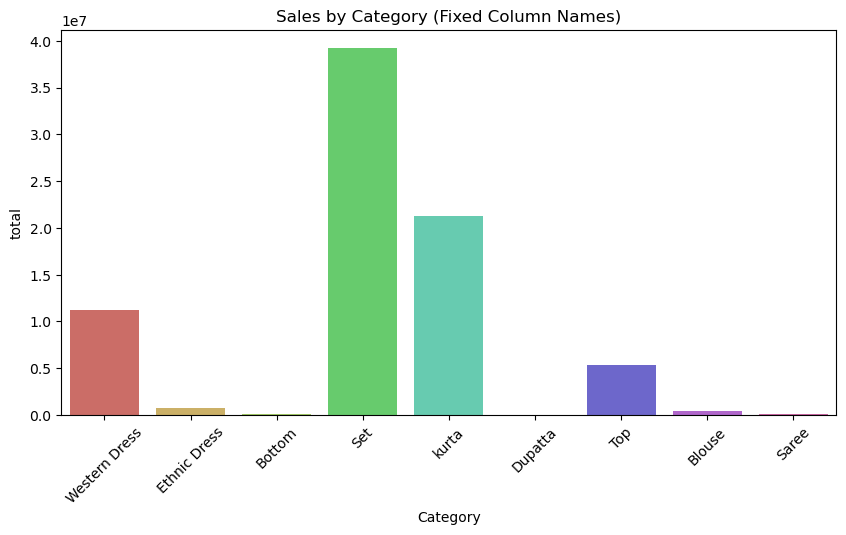

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Run the SQL through pantab to get a DataFrame. Use "Category" and "Amount" (Double quotes are key!)
query = 'SELECT "Category", SUM("Amount") as Total FROM "AmazonSales" GROUP BY 1'
df_summary = pantab.frame_from_hyper_query("ecommerce_cleaned.hyper", query)
print(df_summary)
print("Columns in DataFrame:", df_summary.columns.tolist())

category_col = df_summary.columns[0]
value_col = df_summary.columns[1]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary, x=category_col, y=value_col, 
            palette='hls', hue=category_col, legend=False)
plt.title(f"Sales by {category_col} (Fixed Column Names)")
plt.xticks(rotation=45)
plt.show()